# Strength Training Analysis: Progression and Volume Tracking
## Analysis of Personal Workout Data

This project focuses on cleaning and analyzing personal strength training data to track Progressive Overload and Training Volume. The primary objective is to normalize raw data—accounting for varying equipment weights (Bodyweight, EZ Bars, Barbells)—to calculate an accurate total training load over time.

## Skills Demonstrated:

**Data Cleaning & Normalization**: Standardizing categorical data and handling missing notes.

**Domain-Specific Feature Engineering**: Implementing weight-offset logic for specific exercise types.

**Time-Series Visualization**: Aggregating data by date to analyze longitudinal performance trends.

**Library Proficiency**: Pandas, Matplotlib, Seaborn, and Datetime.

In [17]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/drigupta/warrior-ic/WProgress.csv
/kaggle/input/datasets/drigupta/warrior/Workout Progress - Warrior.csv


### Step 1: Data Foundations & Hygiene
Raw workout logs often contain inconsistencies due to manual entry. Before analysis, we must ensure "data hygiene" is up to standard.

**Temporal Conversion**: Ensuring 'Date' is a datetime object for time-series analysis.

**Handling Missingness**: Replacing empty 'Notes' with placeholders to avoid null-count issues.

**Categorical Standardization**: Correcting typos (e.g., "Staight" to "Straight"), remapping muscle groups for more granular analysis (e.g., separating "Legs" into Anterior/Posterior chains), and ignoring time based ISO hold exercises.

### Step 2: Normalizing Load for Diverse Equipment
A common challenge in strength data is accounting for equipment weight. Calculating "Total Volume" (Reps × Weight) is inaccurate if we ignore the weight of the bar or the athlete's body weight.

I implemented a custom weight mapping system:

**Bodyweight (BW)**: Exercises like Dips/Pullups include an 80kg base.

**Olympic Barbells (BB)**: Standardizing weight to include the 20kg bar.

**EZ Bars**: Accounting for a 10kg bar weight.

In [18]:
#--------- Data Loading, cleaning, preperation ----------#
df = pd.read_csv('/kaggle/input/datasets/drigupta/warrior/Workout Progress - Warrior.csv')

# --- Data Cleaning --- #
df['Date'] = pd.to_datetime(df['Date'])
df.fillna({'Notes':'No Notes'}, inplace = True)

df = df.rename(columns = {'Weight (kg)' : 'Weight', 'Month' : 'Program Month'})
df['Technique'] =  df['Technique'].replace({'Staight':'Straight'})

# --- Correcting Muscle Group Entries --- #
df.loc[(df['Exercise'] == 'DB Push Press') & (df['Muscle Group'] == 'Legs'), 'Muscle Group'] = 'Shoulders'
df.loc[(df['Exercise'] == 'Deadlift') & (df['Muscle Group'] == 'Legs'), 'Muscle Group'] = 'Back'
df.loc[(df['Exercise'] == 'Lat Pulldowns') & (df['Muscle Group'] == 'Chest'), 'Muscle Group'] = 'Back'
df.loc[(df['Exercise'] == 'Seated Cable Rows (Elbows Wide)') & (df['Muscle Group'] == 'Chest'), 'Muscle Group'] = 'Back'
df.loc[(df['Exercise'] == 'Cable Crossover') & (df['Muscle Group'] == 'Back'), 'Muscle Group'] = 'Chest'
df.loc[(df['Exercise'] == 'DB Bench Press') & (df['Muscle Group'] == 'Back'), 'Muscle Group'] = 'Chest'
df.loc[(df['Exercise'] == 'DB Hammer Curls') & (df['Muscle Group'] == 'Triceps'), 'Muscle Group'] = 'Biceps'

# --- Remapping Muscle Groups to reflect anatomical focus --- #
Ant_exercises = ['Alt. Reverse BB Lunges', 'DB Bulgarian Split Squat Hops', 'DB Spanish Squats', 'BB Front Squat', 'DB Reverse Lunges', 'Box Squats', 'DB Step Up Thrusts', 'DB Side Lunges', 'DB Bulgarian Split Squats', 'BB Squats', 'Alt. Reverse DB Lunges', 'DB Step Ups']
Post_exercises = ['BB Hip Thrusts', 'Hamstring Curls', 'Cable Pull Throughs', 'DB Leaning Step Ups', 'BB RDL', 'DB Alt. Reverse Sprinter Lunge', 'Leaning Bulgarian Split Squats', 'DB RDL', 'Alt. DB Leaning Step Ups', "Single Leg Cable RDL's"]
Calf_exercises = ['BB Calf Raises (Toes Out)', 'Seated Calf Raises', 'BB Calf Raises (Toes In)']
df.loc[df['Exercise'].isin(Ant_exercises), 'Muscle Group'] = 'Anterior'
df.loc[df['Exercise'].isin(Post_exercises), 'Muscle Group'] = 'Posterior'
df.loc[df['Exercise'].isin(Calf_exercises), 'Muscle Group'] = 'Calf'

# --- Dataframe without ISO hold exercises (Technique : 3 min) --- #
df = df[df['Technique'] != '3 min']

# --- Constants for equipment weights ---#
B_weight = 80 # Assume 80 kg
EZ_weight = 10 # Assume 10 kg EZ bar
BB_weight = 20 # Assume 20 kg

# --- Exercise Lists for specific equipment types --- #
bw_exercises = ['Dips', 'Plyo Pushups', 'Flexed Arm Hang', 'Hover Hold', 'Wall Sits', 'Chin Ups']
bw_mask = df['Exercise'].isin(bw_exercises)

EZ_exercises = ['Chest Supported BB Rows']
EZ_mask = df['Exercise'].isin(EZ_exercises)

BB_mask = (df['Exercise'].str.contains('BB', na = False) | (df['Exercise'] == 'Deadlift')) & (~df['Exercise'].isin(EZ_exercises))

# Total Weight (with body weight = 80 kg)
df['Total Weight'] = df['Weight']

df.loc[bw_mask, 'Total Weight'] = df['Weight'] + B_weight
df.loc[EZ_mask, 'Total Weight'] = (df['Weight'] * 2) + EZ_weight
df.loc[BB_mask, 'Total Weight'] = (df['Weight'] * 2) + BB_weight

# Added Weight (0 for Body weight)
df['Added Weight'] = df['Weight']

df.loc[EZ_mask, 'Added Weight'] = (df['Weight'] * 2) + EZ_weight
df.loc[BB_mask, 'Added Weight'] = (df['Weight'] * 2) + BB_weight

# Added Weight Volume (0 for Body weight)
df['Added Volume'] = df['Added Weight'] * df['Reps']

# Total Weight Volume (with body weight = 80 kg)
df['Total Volume'] = df['Total Weight'] * df['Reps']

## Step 3: Analysis of Training Trends

The visualization below analyzes the Training Volume by comparing Added Volume (including bar weight) against Total Volume (including bar and body weight).

**Observations**: 
1. The changing levels of intensity during the 12-week workout program present how the program intensity changes throughout. 
2. A widening gap between lines over time would suggest a shift toward more bodyweight exercises.

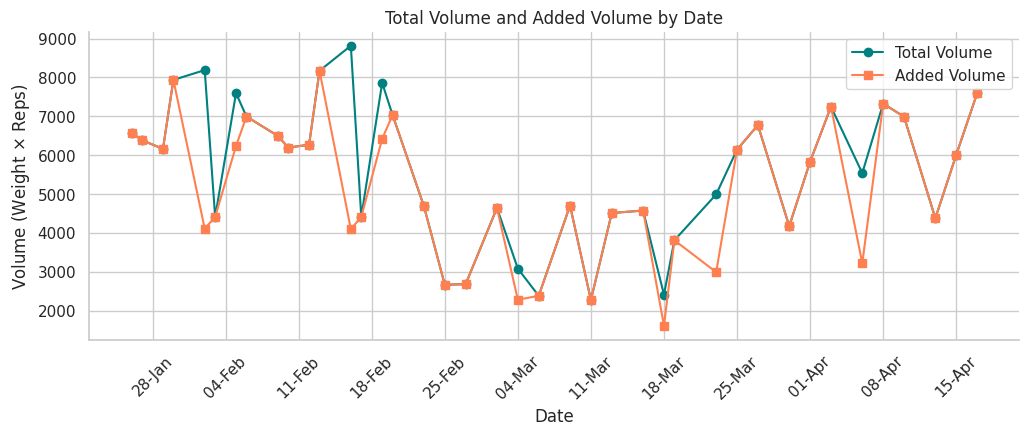

In [19]:
## ------ Plotting Total Daily Training Volume---------#
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook", palette="colorblind")

# Daily Training Volume by day
df_day_volume = df.groupby('Date').agg({'Total Volume' : 'sum', 'Added Volume' : 'sum'})
#print(df_day_volume.head())

# Plotting Daily Volume by date
plt.figure(figsize=(12,4))
plt.plot(df_day_volume.index, df_day_volume['Total Volume'], '-o', color = 'teal', label = 'Total Volume')
plt.plot(df_day_volume.index, df_day_volume['Added Volume'], '-s', color = 'coral', label = 'Added Volume')

plt.title('Total Volume and Added Volume by Date')
plt.xlabel('Date')
plt.ylabel(r'Volume (Weight $\times$ Reps)')
plt.legend()

plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval = 7))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))

for item in plt.gca().xaxis.get_ticklabels():
    item.set_rotation(45)

plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
sns.set()

## Step 4: Analyzing Training Balance via Muscle Groups
To ensure a well-rounded physique and prevent injury, it is critical to monitor the distribution of volume across different muscle groups. By categorizing exercises into different muscle groups, we can identify which muscle groups are receiving the most stimulus and ensure the training split is balanced according to the program goals.

**Observations**
1. The chart identifies which muscle groups contribute most to the total weekly volume. One can observe that in initial works, the volume is not well balanced between muscle groups, with a higher focus on the back. In further weeks, the focus on muscle groups is balanced. One can observe this over the months and weeks.
2. In the heatmap, one can compare the number of sets performed for each muscle group per week, which gives us another metric to analyse the intensity. Many times, it is recommended to perform 8-12 sets per muscle group per week.
3. Any significant deficit in one area could indicate a need to adjust exercise selection to maintain structural balance.


Exercise
Deadlift           26
Hamstring Curls    26
BB Squats          26
BB OHP             26
BB RDL             24
                   ..
DB Spider Curls     2
DB RDL              2
Wrap Around Row     2
DB JM Press         2
DB Push Press       2
Name: count, Length: 90, dtype: int64


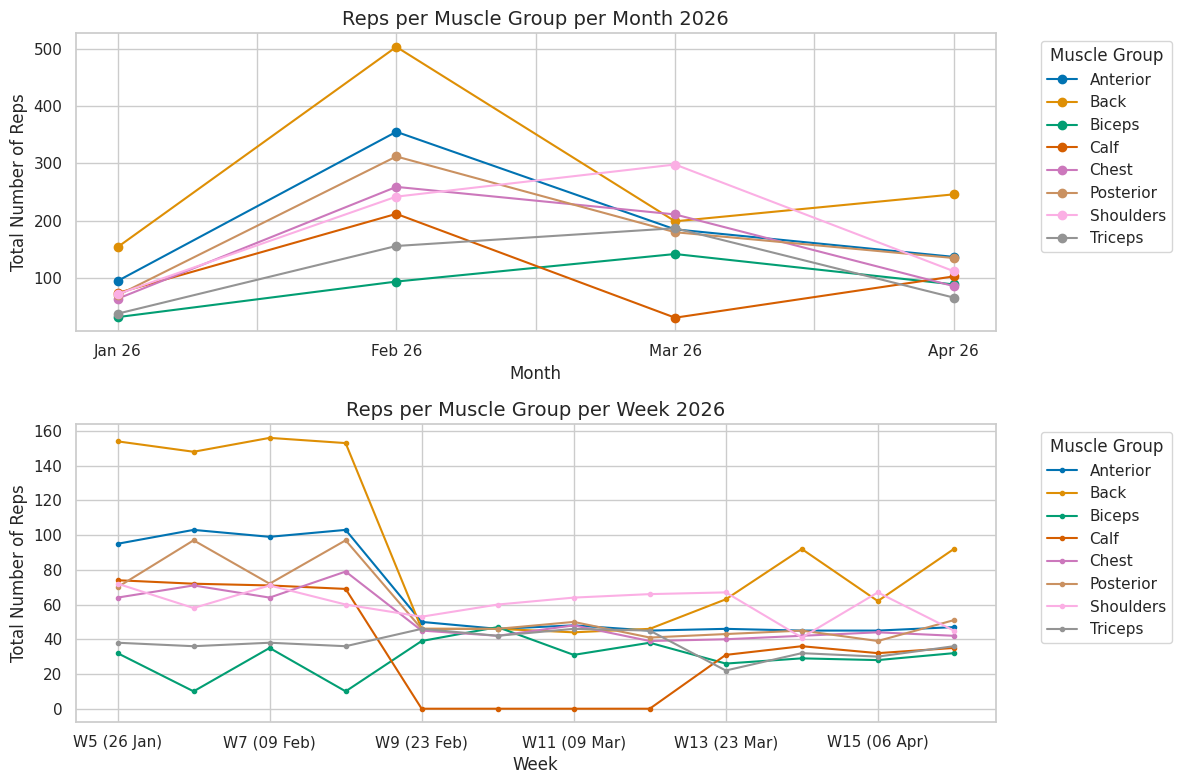

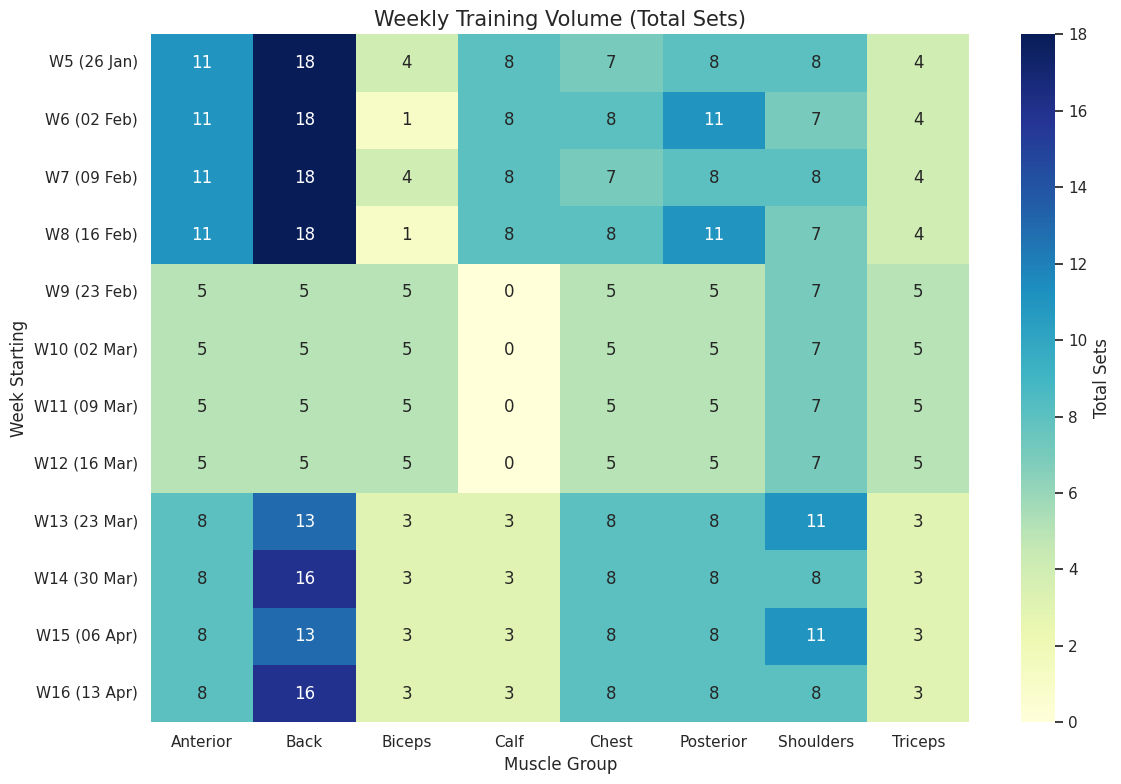

In [20]:
sns.set_theme(style="whitegrid", context="notebook", palette="colorblind")
# --------- Per Muscle Group Reps per calendar month and per calendar week --------- #
#print(df.columns)
df['Month'] = df['Date'].dt.to_period('M')
df['Week'] = df['Date'].dt.to_period('W')

# Number of Reps per muscle Group
df_group_volume_month = df.groupby([df['Month'], df['Muscle Group']]).agg({'Reps':'sum'}).unstack()
df_group_volume_month = df_group_volume_month['Reps'] # to flaten out column and clean legend name
df_group_volume_month = df_group_volume_month.fillna(0)
df_group_volume_month.index = [p.strftime('%b %y') for p in df_group_volume_month.index]


df_group_volume_week = df.groupby([df['Week'], df['Muscle Group']]).agg({'Reps':'sum'}).unstack()
df_group_volume_week = df_group_volume_week['Reps'] # to flaten out column and clean legend name
df_group_volume_week = df_group_volume_week.fillna(0)
df_group_volume_week.index = [f"W{p.week} ({p.start_time.strftime('%d %b')})" for p in df_group_volume_week.index]

# --------- Plotting Sets per muscle group by month ---------- #

fig, (ax1, ax2) = plt.subplots(2, 1, figsize = (12, 8))

df_group_volume_month.plot(kind = 'line', marker = 'o', ax = ax1)
ax1.set_title('Reps per Muscle Group per Month 2026', fontsize=14)
ax1.set_ylabel('Total Number of Reps')
ax1.set_xlabel('Month')
ax1.legend(title='Muscle Group', bbox_to_anchor=(1.2, 1), loc='upper right')

df_group_volume_week.plot(kind = 'line', marker = '.', ax = ax2)
ax2.set_title('Reps per Muscle Group per Week 2026', fontsize=14)
ax2.set_ylabel('Total Number of Reps')
ax2.set_xlabel('Week')
ax2.legend(title='Muscle Group', bbox_to_anchor=(1.2, 1), loc='upper right')

plt.tight_layout()

# Heavy Hitters
mask_heavy = df['Added Weight'] >= 50.0
df_heavy = df[mask_heavy]
df_heavy = df_heavy.sort_values('Added Weight', ascending = False)
print(df['Exercise'].value_counts())

# --- Heat Map of Weekly Training Volume --- #
df_group_sets_week = df.groupby([df['Week'], df['Muscle Group']]).size().unstack()
df_group_sets_week = df_group_sets_week.fillna(0)
df_group_sets_week.index = [f"W{p.week} ({p.start_time.strftime('%d %b')})" for p in df_group_sets_week.index]

plt.figure(figsize=(12, 8))

# Use your processed df_group_volume_week here
sns.heatmap(df_group_sets_week, annot=True, fmt=".0f", cmap="YlGnBu", cbar_kws={'label': 'Total Sets'})

plt.title('Weekly Training Volume (Total Sets)', fontsize=15)
plt.xlabel('Muscle Group')
plt.ylabel('Week Starting')
plt.tight_layout()
plt.show()

## Step 5: Tracking Absolute Strength (Estimated 1RM)
While total volume tracks endurance and workload, the Estimated 1 Rep Max (1RM) is the gold standard for tracking absolute strength. Using the Brzycki Formula (Weight×(36/(37−Reps))), we can normalize sets of varying intensities to a single comparable value.

I focused the analysis on two categories:

**The Big Three**: Bench Press, Squat, and Deadlift (Fundamental compound movements).

**Top Three Frequent**: The exercises performed most consistently to ensure data reliability over time.

**Observations**
1. **Compound Strength**: The "Big Three" plot illustrates the trajectory of absolute strength. Steady upward slopes indicate successful Progressive Overload.
2. **Consistency & Plateaus**: By looking at the "Top Three" plot, we can identify periods of stagnation (plateaus). These insights are actionable, suggesting when it may be time to change repetition ranges or introduce a "deload" week.


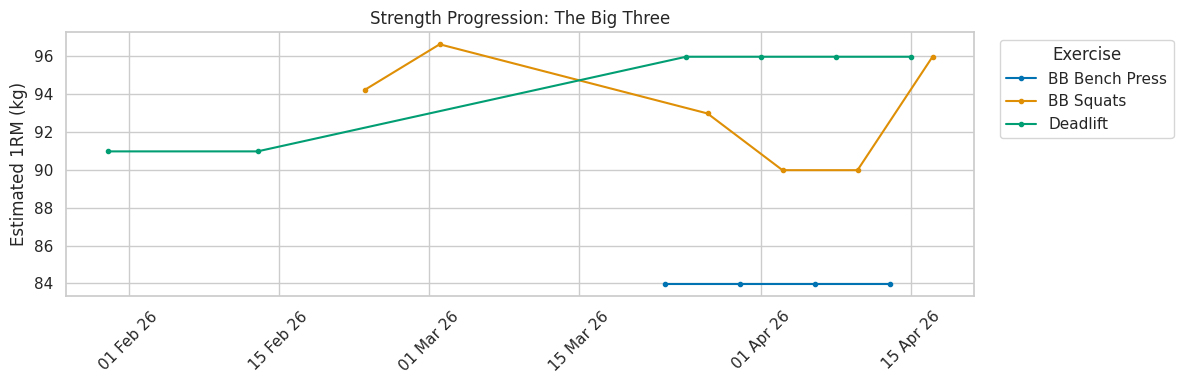

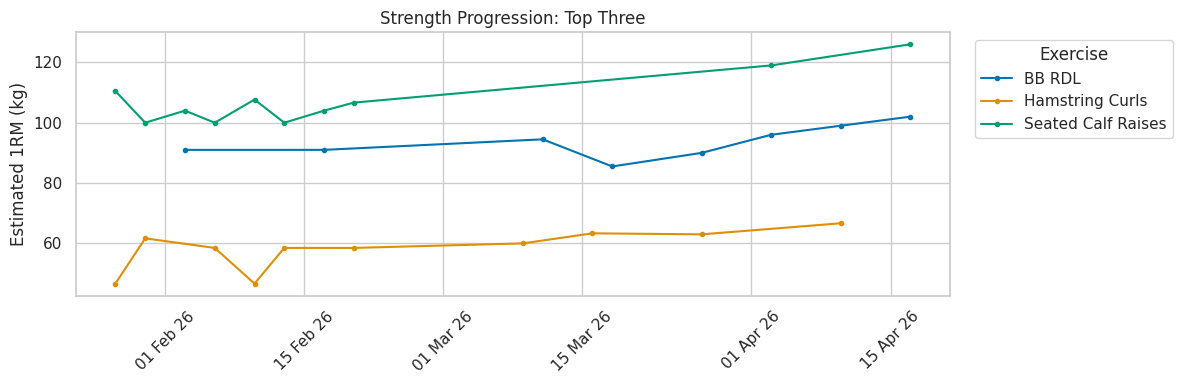

In [21]:
sns.set_theme(style="whitegrid", context="notebook", palette="colorblind")
# 1 Rep Max calculation
def one_rpm(weight, reps):
    if reps == 1: # 1 Rep sets have been done with submaximal efforts
        one_rep_max = None
    else:
        one_rep_max = weight * (1 + (0.0333 * reps))
    return one_rep_max

df['1 RPM'] = df.apply(lambda x: one_rpm(x['Added Weight'], x['Reps']), axis = 1)

# --- 1 Rep Max of the day of Big 3 ---#
big_3 = ['BB Squats', 'BB Bench Press', 'Deadlift']
mask_big_3 = df['Exercise'].isin(big_3) 
df_big_3 = df[mask_big_3].pivot_table(values = '1 RPM', index = 'Date', columns = 'Exercise', aggfunc = (['max']))['max']#.fillna('Not Perf')

# --- Plot --- #
plt.figure(figsize = (12,4))
for exercise in df_big_3.columns:
    valid_data = df_big_3[exercise].dropna()
    #valid_data.index = [p.strfdate('%d %b %y') for p in valid_data.index]
    plt.plot(valid_data.index, valid_data.values, marker = '.', label = exercise)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d %b %y'))
plt.title("Strength Progression: The Big Three")
plt.ylabel("Estimated 1RM (kg)")
plt.xticks(rotation = 45)
plt.legend(title = 'Exercise', bbox_to_anchor = (1.02,1))
plt.tight_layout()

# --- 1 Rep Max of the day of Top 3 Most Frequent Exercises ---#
frequent_exercise = df.groupby('Exercise')['Date'].nunique().sort_values(ascending = False)[:3]
top_3_exercises = frequent_exercise.index
top_3_mask = df['Exercise'].isin(top_3_exercises)
df_top_3 = df[top_3_mask].pivot_table(values = '1 RPM', index = 'Date', columns = 'Exercise', aggfunc = (['max']))['max']

# --- Plot --- #
plt.figure(figsize = (12,4))
for exercise in df_top_3.columns:
    valid_data = df_top_3[exercise].dropna()
    plt.plot(valid_data.index, valid_data.values, marker = '.', label = exercise)


plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d %b %y'))
plt.title("Strength Progression: Top Three")
plt.ylabel("Estimated 1RM (kg)")
plt.xticks(rotation = 45)
plt.legend(title = 'Exercise', bbox_to_anchor = (1.02,1))
plt.tight_layout()

sns.set()
    
